# Student Performance Analysis

## Project Overview

This project analyzes student academic performance using Python.

The project includes:

- Data loading and exploration
- Missing value handling
- Score calculation
- Grade assignment
- Student ranking
- Department-wise analysis
- Data visualization

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab
- GitHub

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    "Name": ["Abinaya", "Priya", "Anu", "Kavi", "Ravi", "Divya", "Arun", "Meena"],
    "Department": ["ECE", "CSE", "ECE", "CSE", "ECE", "CSE", "ECE", "CSE"],
    "Age": [22, 21, 23, np.nan, 20, 22, 21, 23],
    "Math": [85, 72, 90, 65, 95, np.nan, 78, 88],
    "Science": [90, 80, np.nan, 70, 88, 92, 75, 85],
    "Attendance": [95, 88, 92, 75, 98, 90, np.nan, 85]
}

df = pd.DataFrame(data)

df

df.head()
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        8 non-null      object 
 1   Department  8 non-null      object 
 2   Age         7 non-null      float64
 3   Math        7 non-null      float64
 4   Science     7 non-null      float64
 5   Attendance  7 non-null      float64
dtypes: float64(4), object(2)
memory usage: 516.0+ bytes


,0
Name,0
Department,0
Age,1
Math,1
Science,1
Attendance,1


In [72]:
df["Age"] = df["Age"].fillna(df["Age"].mean())


In [73]:

df["Math"] = df["Math"].fillna(df["Math"].mean())


In [74]:

df["Science"] = df["Science"].fillna(df["Science"].mean())


In [75]:

df["Attendance"] = df["Attendance"].fillna(df["Attendance"].mean())


In [76]:

df.isnull().sum()

,0
Name,0
Department,0
Age,0
Math,0
Science,0
Attendance,0
Total,0
Average,0
Grade,0


In [77]:
df["Total"] = df["Math"] + df["Science"]


In [78]:
df['Average'] = df['Total']/2
df

,Name,Department,Age,Math,Science,Attendance,Total,Average,Grade
0,Abinaya,ECE,22.000000,85.000000,90.000000,95.0,175.000000,87.500000,B
1,Priya,CSE,21.000000,72.000000,80.000000,88.0,152.000000,76.000000,C
2,Anu,ECE,23.000000,90.000000,82.857143,92.0,172.857143,86.428571,B
3,Kavi,CSE,21.714286,65.000000,70.000000,75.0,135.000000,67.500000,D
4,Ravi,ECE,20.000000,95.000000,88.000000,98.0,183.000000,91.500000,A
5,Divya,CSE,22.000000,81.857143,92.000000,90.0,173.857143,86.928571,B
6,Arun,ECE,21.000000,78.000000,75.000000,89.0,153.000000,76.500000,C
7,Meena,CSE,23.000000,88.000000,85.000000,85.0,173.000000,86.500000,B


In [56]:
def get_grade(avg):
    if avg >= 90:
        return "A"
    elif avg >= 80:
        return "B"
    elif avg >= 70:
        return "C"
    elif avg >= 60:
        return "D"
    else:
        return "F"



In [57]:
df["Grade"] = df["Average"].apply(get_grade)

In [58]:
df[["Name", "Average", "Grade"]]

,Name,Average,Grade
0,Abinaya,87.500000,B
1,Priya,76.000000,C
2,Anu,86.428571,B
3,Kavi,67.500000,D
4,Ravi,91.500000,A
5,Divya,86.928571,B
6,Arun,76.500000,C
7,Meena,86.500000,B


In [59]:
df.loc[df["Average"] >= 80, ["Name", "Average", "Grade"]]


,Name,Average,Grade
0,Abinaya,87.500000,B
2,Anu,86.428571,B
4,Ravi,91.500000,A
5,Divya,86.928571,B
7,Meena,86.500000,B


In [60]:
df.loc[df["Attendance"] >= 90, ["Name", "Attendance"]]

,Name,Attendance
0,Abinaya,95.0
2,Anu,92.0
4,Ravi,98.0
5,Divya,90.0


In [61]:
df.loc[df["Average"] < 70, ["Name", "Average", "Grade"]]

,Name,Average,Grade
3,Kavi,67.5,D


In [62]:
ranked_df = df.sort_values("Average", ascending=False)

ranked_df[["Name", "Department", "Average", "Grade"]]

,Name,Department,Average,Grade
4,Ravi,ECE,91.500000,A
0,Abinaya,ECE,87.500000,B
5,Divya,CSE,86.928571,B
7,Meena,CSE,86.500000,B
2,Anu,ECE,86.428571,B
6,Arun,ECE,76.500000,C
1,Priya,CSE,76.000000,C
3,Kavi,CSE,67.500000,D


In [63]:
top_3 = df.sort_values("Average", ascending=False).head(3)

top_3[["Name", "Average", "Grade"]]

,Name,Average,Grade
4,Ravi,91.500000,A
0,Abinaya,87.500000,B
5,Divya,86.928571,B


In [64]:
df.nlargest(3, "Average")[["Name", "Average", "Grade"]]

,Name,Average,Grade
4,Ravi,91.500000,A
0,Abinaya,87.500000,B
5,Divya,86.928571,B


In [65]:
df.groupby("Department")["Math"].mean()

,Math
Department,
CSE,76.714286
ECE,87.000000


In [68]:
df.groupby("Department")["Science"].mean()

,Science
Department,
CSE,81.750000
ECE,83.964286


In [69]:
df.groupby("Department")[["Math", "Science", "Average"]].mean()

,Math,Science,Average
Department,,,
CSE,76.714286,81.750000,79.232143
ECE,87.000000,83.964286,85.482143


In [70]:
df.groupby("Department")["Math"].max()

,Math
Department,
CSE,88.0
ECE,95.0


In [71]:
df.groupby("Department")["Science"].max()

,Science
Department,
CSE,92.0
ECE,90.0


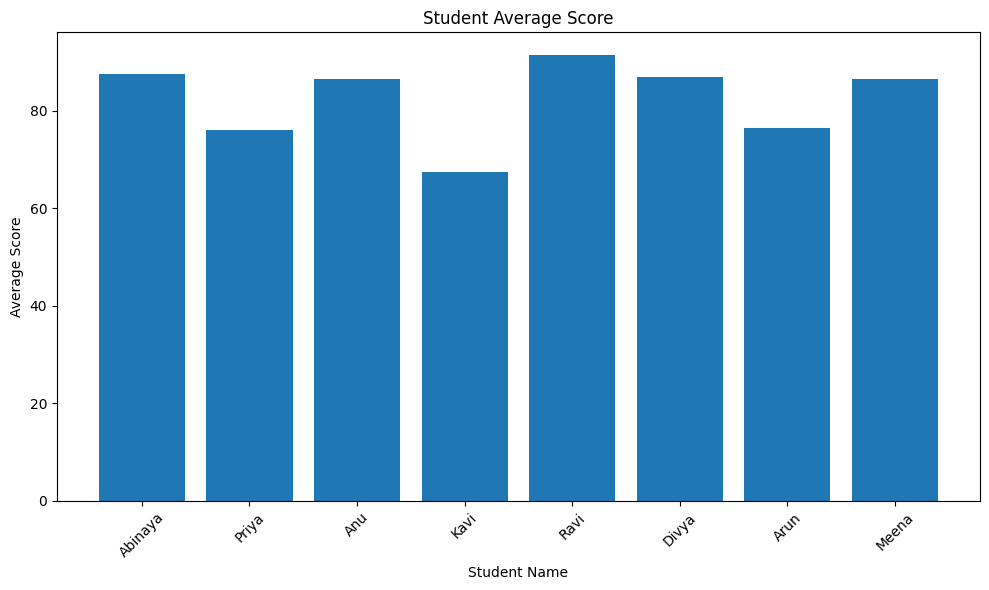

In [79]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.bar(df["Name"], df["Average"])

plt.title("Student Average Score")
plt.xlabel("Student Name")
plt.ylabel("Average Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [80]:
department_avg = df.groupby("Department")["Average"].mean()

department_avg

,Average
Department,
CSE,79.232143
ECE,85.482143


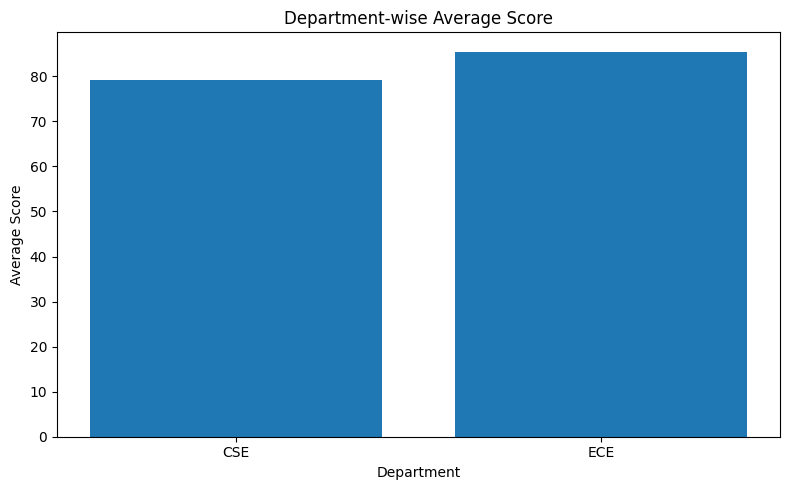

In [81]:
plt.figure(figsize=(8, 5))

plt.bar(department_avg.index, department_avg.values)

plt.title("Department-wise Average Score")
plt.xlabel("Department")
plt.ylabel("Average Score")

plt.tight_layout()
plt.show()

In [82]:
subject_avg = df.groupby("Department")[["Math", "Science"]].mean()

subject_avg

,Math,Science
Department,,
CSE,76.714286,81.750000
ECE,87.000000,83.964286


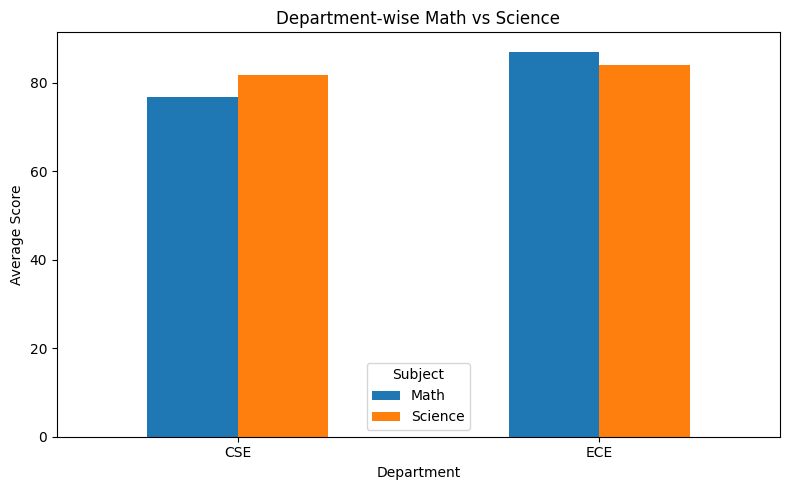

In [83]:
subject_avg.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Department-wise Math vs Science")
plt.xlabel("Department")
plt.ylabel("Average Score")

plt.xticks(rotation=0)
plt.legend(title="Subject")

plt.tight_layout()
plt.show()

In [84]:
attendance_avg = df.groupby("Department")["Attendance"].mean()

attendance_avg


,Attendance
Department,
CSE,84.5
ECE,93.5


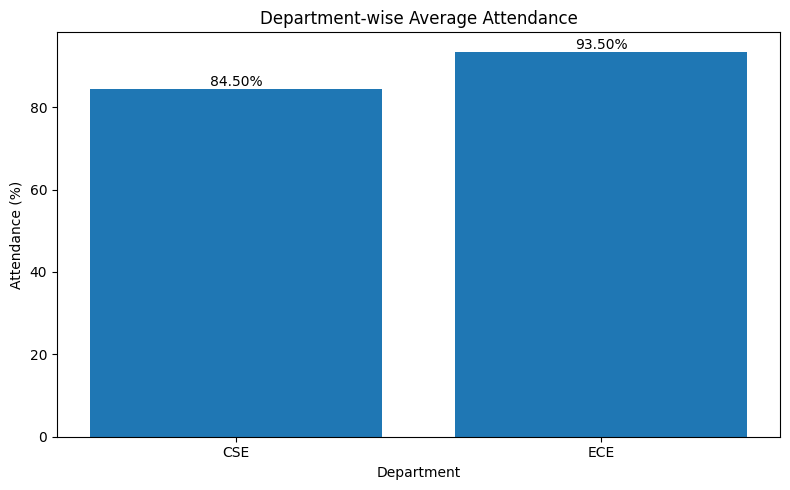

In [85]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    attendance_avg.index,
    attendance_avg.values
)

plt.title("Department-wise Average Attendance")
plt.xlabel("Department")
plt.ylabel("Attendance (%)")

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [86]:
top_student = df.loc[df["Average"].idxmax()]

top_student

,4
Name,Ravi
Department,ECE
Age,20.0
Math,95.0
Science,88.0
Attendance,98.0
Total,183.0
Average,91.5
Grade,A


In [87]:
correlation = df[["Math", "Science", "Attendance", "Average"]].corr()

print(correlation)

                Math   Science  Attendance   Average
Math        1.000000  0.723271    0.794570  0.946646
Science     0.723271  1.000000    0.738322  0.907233
Attendance  0.794570  0.738322    1.000000  0.828542
Average     0.946646  0.907233    0.828542  1.000000


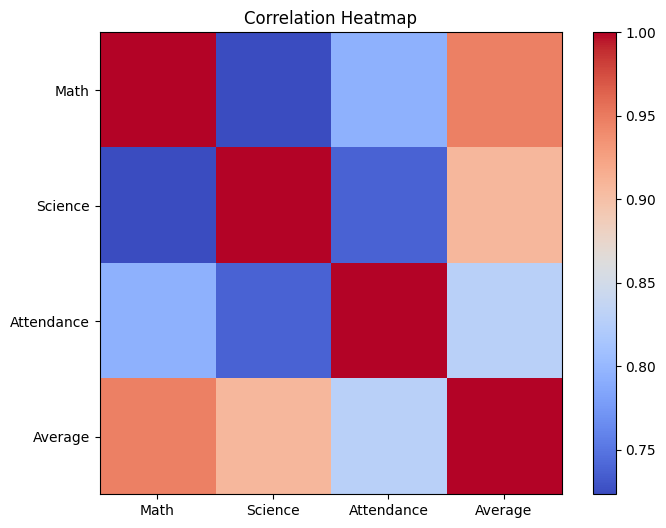

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

In [89]:
df.to_csv("student_performance_final.csv", index=False)

print("Final dataset saved successfully!")


Final dataset saved successfully!
